# 06 — Model M4, konfiguracja stabilizowana

Wariant modelu zespolonego z trzema mechanizmami stabilizującymi wprowadzonymi
łącznie: wygładzaniem etykiet (0,05), harmonogramem `OneCycleLR` oraz zaostrzonym
przycinaniem gradientu (1,0 zamiast 5,0). Maksymalną liczbę epok ograniczono do 60,
zwiększając cierpliwość wczesnego zatrzymania do 25.

Wariant stanowi odrębny eksperyment optymalizacyjny i nie wchodzi w skład
zasadniczego porównania: odmienna procedura uczenia uniemożliwia zestawienie go
z modelami rzeczywistymi.

| | |
|---|---|
| UAR (nagrania) | 0,4925 ± 0,0186 |
| zmiana względem konfiguracji podstawowej | +2,10 p.p., CI [−0,10; +4,09] |

## 1. Konfiguracja

In [1]:

import sys, json, time, random, math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- ścieżki ----------
ON_KAGGLE = Path("/kaggle/input").exists()
DATA = (Path("/kaggle/input/datasets/julkagromna/ser-processed") if ON_KAGGLE
        else Path("../data/processed"))
WORK = Path("/kaggle/working") if ON_KAGGLE else Path("../results")
RESULTS = WORK / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

# ---------- sygnał ----------
SR = 16000
SEG_SEC = 1.0
SEG_LEN = int(SEG_SEC * SR)

# ---------- STFT ----------
N_FFT, WIN_LENGTH, HOP_LENGTH = 512, 400, 160
CENTER = True
N_FRAMES = SEG_LEN // HOP_LENGTH + 1     
N_BINS = N_FFT // 2 + 1                 
POWER_COMPRESSION = 0.3

# ---------- klasy ----------
EMOTIONS = ["ANG", "DIS", "FEA", "HAP", "NEU", "SAD"]
EMOTION_PL = {"ANG": "złość", "DIS": "wstręt", "FEA": "strach",
              "HAP": "radość", "NEU": "neutralny", "SAD": "smutek"}
LABEL2ID = {e: i for i, e in enumerate(EMOTIONS)}
ID2LABEL = {i: e for e, i in LABEL2ID.items()}
N_CLASSES = len(EMOTIONS)

# ---------- hiperparametry ----------
BATCH_SIZE = 64          
MAX_EPOCHS = 60
PATIENCE = 25
LR = 1e-3  
WEIGHT_DECAY = 1e-4
SEEDS = [42,43,44,45,46]             

LABEL_SMOOTHING = 0.05     
CLIP_NORM = 1.0           

# ---------- rozmiar architektury ----------
CH = (23, 45, 90, 90)    
RNN_HIDDEN = 90          

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


print("urządzenie :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU        :", torch.cuda.get_device_name(0))
else:
    print("UWAGA: brak GPU — Session options → Accelerator → GPU T4 x2")

manifest = pd.read_csv(DATA / "manifest.csv")
print(f"\nsegmentów: {len(manifest)} | nagrań: {manifest.file_id.nunique()}")
print(manifest.groupby("split").size().to_string())

urządzenie : cuda
GPU        : Tesla T4

segmentów: 30568 | nagrań: 7441
split
test      4731
train    21151
val       4686


## 2. Dane i transformata STFT

Transformata wyznaczana jest bezpośrednio na akceleratorze graficznym, przy
identycznych parametrach analizy co w pozostałych modelach.

In [2]:
manifest = pd.read_csv(DATA/ "manifest.csv")
WINDOW = torch.hann_window(WIN_LENGTH, periodic=True, device=DEVICE)


def stft_batch(wav: torch.Tensor) -> torch.Tensor:
    Z = torch.stft(wav, n_fft=N_FFT, hop_length=HOP_LENGTH,
                   win_length=WIN_LENGTH, window=WINDOW,
                   center=CENTER, pad_mode="constant", return_complex=True)
    mag = Z.abs().clamp_min(1e-8)
    Z = Z * (mag ** (POWER_COMPRESSION - 1.0))     
    return Z.unsqueeze(1)


class WavSplit:
    def __init__(self, split):
        X = np.load(DATA / f"X_{split}.npy")
        X = torch.from_numpy(X).float()
        if X.abs().max() > 1.5:                        
            X = X / 32767.0
        self.X = X.to(DEVICE)
        self.meta = manifest[manifest.split == split].sort_values("idx").reset_index(drop=True)
        self.y = torch.from_numpy(self.meta.label.values.astype(np.int64)).to(DEVICE)
        assert len(self.X) == len(self.y), "niezgodnosc danych i manifestu"

    def __len__(self):
        return len(self.y)


def batches(d, bs, shuffle=False, generator=None, drop_last=False):
    n = len(d)
    idx = torch.randperm(n, generator=generator) if shuffle else torch.arange(n)
    idx = idx.to(DEVICE)
    stop = n - (n % bs if drop_last else 0)
    for i in range(0, stop, bs):
        j = idx[i:i + bs]
        yield d.X[j], d.y[j]


ds = {s: WavSplit(s) for s in ["train", "val", "test"]}
for s, d in ds.items():
    print(f"{s:5s}: {len(d):6d} segmentow | {d.X.nelement()*4/1e9:.2f} GB na GPU")

train:  21151 segmentow | 1.35 GB na GPU
val  :   4686 segmentow | 0.30 GB na GPU
test :   4731 segmentow | 0.30 GB na GPU


## 3. Normalizacja

Podział przez wartość skuteczną modułu wyznaczoną osobno dla każdego prążka.
Współczynnik skalujący jest wielkością rzeczywistą, wobec czego operacja nie
modyfikuje kąta fazowego.

In [3]:
with torch.no_grad():
    acc, n = 0.0, 0
    for xb, _ in batches(ds["train"], 256):
        Z = stft_batch(xb)
        acc = acc + (Z.abs() ** 2).sum(dim=(0, 1, 3))
        n += xb.shape[0] * Z.shape[-1]
    RMS = torch.sqrt(acc / n).clamp_min(1e-8).view(1, 1, -1, 1)

print("ksztalt wspolczynnikow normalizacji:", tuple(RMS.shape))
print(f"zakres: {RMS.min().item():.4f} ... {RMS.max().item():.4f}")

counts = np.bincount(ds["train"].y.cpu().numpy(), minlength=N_CLASSES)
weights = counts.sum() / (N_CLASSES * counts)
CLASS_W = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
print()
print(pd.DataFrame({"klasa": EMOTIONS, "segmentow": counts,
                    "waga": weights.round(3)}).to_string(index=False))

ksztalt wspolczynnikow normalizacji: (1, 1, 257, 1)
zakres: 0.4041 ... 1.4406

klasa  segmentow  waga
  ANG       3106 1.135
  DIS       4160 0.847
  FEA       3565 0.989
  HAP       3277 1.076
  NEU       3108 1.134
  SAD       3935 0.896


## 4. Warstwy zespolone

Operacje niedostępne w standardowej bibliotece PyTorch, zaimplementowane
samodzielnie. Poprawność zweryfikowano w notatniku `07_testy_jednostkowe`.

| operacja | realizacja |
|---|---|
| splot | cztery sploty rzeczywiste |
| normalizacja | wybielanie macierzy kowariancji 2×2 |
| aktywacja | ℂReLU |
| redukcja | selekcja według modułu |
| rekurencja | bramki z modułu, stan ukryty w ℂ |

In [4]:
class ComplexConv2d(nn.Module):
    def __init__(self, cin, cout, k=3, padding=1):
        super().__init__()
        self.cr = nn.Conv2d(cin, cout, k, padding=padding, bias=False)
        self.ci = nn.Conv2d(cin, cout, k, padding=padding, bias=False)
        self._init_complex(cin * k * k)

    def _init_complex(self, fan_in):
        sigma = 1.0 / math.sqrt(2 * fan_in)
        for w_r, w_i in [(self.cr.weight, self.ci.weight)]:
            with torch.no_grad():
                mag = torch.from_numpy(
                    np.random.rayleigh(sigma, size=tuple(w_r.shape))).float()
                phase = torch.empty_like(w_r).uniform_(-math.pi, math.pi)
                w_r.copy_(mag * torch.cos(phase))
                w_i.copy_(mag * torch.sin(phase))

    def forward(self, z):
        zr, zi = z.real, z.imag
        return torch.complex(self.cr(zr) - self.ci(zi),
                             self.cr(zi) + self.ci(zr))

In [5]:
class ComplexBatchNorm2d(nn.Module):
    def __init__(self, c, eps=1e-5, momentum=0.1):
        super().__init__()
        self.eps, self.momentum = eps, momentum
        self.g_rr = nn.Parameter(torch.full((c,), 1 / math.sqrt(2)))
        self.g_ii = nn.Parameter(torch.full((c,), 1 / math.sqrt(2)))
        self.g_ri = nn.Parameter(torch.zeros(c))
        self.b_r = nn.Parameter(torch.zeros(c))
        self.b_i = nn.Parameter(torch.zeros(c))
        for n, v in [("rm_r", torch.zeros(c)), ("rm_i", torch.zeros(c)),
                     ("rv_rr", torch.full((c,), 1 / math.sqrt(2))),
                     ("rv_ii", torch.full((c,), 1 / math.sqrt(2))),
                     ("rv_ri", torch.zeros(c))]:
            self.register_buffer(n, v)

    def forward(self, z):
        zr, zi = z.real, z.imag
        dims = (0, 2, 3)
        if self.training:
            mr, mi = zr.mean(dims), zi.mean(dims)
            with torch.no_grad():
                self.rm_r.mul_(1 - self.momentum).add_(self.momentum * mr)
                self.rm_i.mul_(1 - self.momentum).add_(self.momentum * mi)
        else:
            mr, mi = self.rm_r, self.rm_i

        v = lambda t: t.view(1, -1, 1, 1)
        xr, xi = zr - v(mr), zi - v(mi)

        if self.training:
            vrr = (xr * xr).mean(dims) + self.eps
            vii = (xi * xi).mean(dims) + self.eps
            vri = (xr * xi).mean(dims)
            with torch.no_grad():
                self.rv_rr.mul_(1 - self.momentum).add_(self.momentum * vrr)
                self.rv_ii.mul_(1 - self.momentum).add_(self.momentum * vii)
                self.rv_ri.mul_(1 - self.momentum).add_(self.momentum * vri)
        else:
            vrr, vii, vri = self.rv_rr, self.rv_ii, self.rv_ri

        det = (vrr * vii - vri * vri).clamp_min(self.eps)
        s = torch.sqrt(det)
        t = torch.sqrt(vrr + vii + 2 * s).clamp_min(self.eps)
        inv = 1.0 / (s * t)
        wrr, wii, wri = (vii + s) * inv, (vrr + s) * inv, -vri * inv

        nr = v(wrr) * xr + v(wri) * xi
        ni = v(wri) * xr + v(wii) * xi

        outr = v(self.g_rr) * nr + v(self.g_ri) * ni + v(self.b_r)
        outi = v(self.g_ri) * nr + v(self.g_ii) * ni + v(self.b_i)
        return torch.complex(outr, outi)


def crelu(z):
    return torch.complex(F.relu(z.real), F.relu(z.imag))

In [6]:
class ComplexLinear(nn.Module):
    def __init__(self, cin, cout, bias=True):
        super().__init__()
        self.lr = nn.Linear(cin, cout, bias=False)
        self.li = nn.Linear(cin, cout, bias=False)
        self.use_bias = bias
        if bias:
            self.b_r = nn.Parameter(torch.zeros(cout))
            self.b_i = nn.Parameter(torch.zeros(cout))
        sigma = 1.0 / math.sqrt(2 * cin)
        with torch.no_grad():
            mag = torch.from_numpy(
                np.random.rayleigh(sigma, size=tuple(self.lr.weight.shape))).float()
            phase = torch.empty_like(self.lr.weight).uniform_(-math.pi, math.pi)
            self.lr.weight.copy_(mag * torch.cos(phase))
            self.li.weight.copy_(mag * torch.sin(phase))

    def forward(self, z):
        zr, zi = z.real, z.imag
        out_r = self.lr(zr) - self.li(zi)
        out_i = self.lr(zi) + self.li(zr)
        if self.use_bias:
            out_r = out_r + self.b_r
            out_i = out_i + self.b_i
        return torch.complex(out_r, out_i)


class ComplexGRUCell(nn.Module):
    def __init__(self, cin, hidden):
        super().__init__()
        self.hidden = hidden
        self.x2h = ComplexLinear(cin, 3 * hidden)
        self.h2h = ComplexLinear(hidden, 3 * hidden, bias=False)

    def forward(self, x, h):
        gx = self.x2h(x)
        gh = self.h2h(h)
        H = self.hidden
        z = torch.sigmoid((gx[:, :H] + gh[:, :H]).abs())          
        r = torch.sigmoid((gx[:, H:2*H] + gh[:, H:2*H]).abs())    
        n = gx[:, 2*H:] + r.to(gh.dtype) * gh[:, 2*H:]
        n = torch.complex(torch.tanh(n.real), torch.tanh(n.imag))  
        zc = z.to(h.dtype)
        return (1 - zc) * n + zc * h


class ComplexBiGRU(nn.Module):
    def __init__(self, cin, hidden):
        super().__init__()
        self.fwd = ComplexGRUCell(cin, hidden)
        self.bwd = ComplexGRUCell(cin, hidden)
        self.hidden = hidden

    def forward(self, x):                     
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden, dtype=x.dtype, device=x.device)
        out_f = []
        for t in range(T):
            h = self.fwd(x[:, t], h)
            out_f.append(h)
        h = torch.zeros(B, self.hidden, dtype=x.dtype, device=x.device)
        out_b = []
        for t in reversed(range(T)):
            h = self.bwd(x[:, t], h)
            out_b.append(h)
        out_b.reverse()
        return torch.cat([torch.stack(out_f, 1), torch.stack(out_b, 1)], dim=-1)

In [7]:
lay = ComplexLinear(8, 5)
with torch.no_grad():
    lay.b_r.normal_(); lay.b_i.normal_()

z = torch.randn(4, 8, dtype=torch.complex64)
W = torch.complex(lay.lr.weight, lay.li.weight)
b = torch.complex(lay.b_r, lay.b_i)
err = (lay(z) - (z @ W.T + b)).abs().max().item()
print(f"blad: {err:.2e}")
assert err < 1e-5

blad: 1.19e-07


## 5. Architektura

Przejście z dziedziny zespolonej do rzeczywistej następuje jednokrotnie, przez
wyznaczenie modułu na wyjściu bloku rekurencyjnego.

In [8]:
class ComplexConvBlock(nn.Module):
    def __init__(self, cin, cout, pool):
        super().__init__()
        self.conv = ComplexConv2d(cin, cout)
        self.bn = ComplexBatchNorm2d(cout)
        self.pool = pool

    def forward(self, z):
        z = crelu(self.bn(self.conv(z)))
        pf, pt = self.pool
        mag = z.abs()
        _, idx = F.max_pool2d(mag, (pf, pt), return_indices=True)
        B, C, H, W = z.shape
        flat_r = z.real.reshape(B, C, -1).gather(2, idx.reshape(B, C, -1))
        flat_i = z.imag.reshape(B, C, -1).gather(2, idx.reshape(B, C, -1))
        shp = idx.shape
        return torch.complex(flat_r.reshape(shp), flat_i.reshape(shp))


class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.w = nn.Linear(dim, 1)

    def forward(self, x):
        a = torch.softmax(self.w(x), dim=1)
        return (x * a).sum(dim=1)


class CVRCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES, ch=CH, rnn_hidden=RNN_HIDDEN):
        super().__init__()
        pools = [(4, 2), (4, 2), (4, 1), (2, 1)]
        blocks, cin = [], 1
        for cout, p in zip(ch, pools):
            blocks.append(ComplexConvBlock(cin, cout, p)); cin = cout
        self.blocks = nn.ModuleList(blocks)

        with torch.no_grad():
            d = torch.complex(torch.zeros(1, 1, N_BINS, N_FRAMES),
                              torch.zeros(1, 1, N_BINS, N_FRAMES))
            for b in self.blocks:
                d = b(d)
            c, f, t = d.shape[1:]
        self.seq_dim, self.seq_len = c * f, t

        self.rnn = ComplexBiGRU(self.seq_dim, rnn_hidden)
        self.att = AttentionPool(2 * rnn_hidden)
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(2 * rnn_hidden, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, z):
        for b in self.blocks:
            z = b(z)
        z = z.permute(0, 3, 1, 2).flatten(2)     
        z = self.rnn(z)                          
        return self.head(self.att(z.abs()))      


m = CVRCNN().to(DEVICE)
n_par = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"sekwencja: dlugosc {m.seq_len}, wymiar {m.seq_dim} zespolonych")
print(f"parametry uczone (rzeczywiste): {n_par:,}")

with torch.no_grad():
    xb, _ = next(iter(batches(ds["train"], 4)))
    out = m(stft_batch(xb) / RMS)
print("ksztalt wyjscia:", tuple(out.shape))
del m

sekwencja: dlugosc 25, wymiar 180 zespolonych
parametry uczone (rzeczywiste): 543,819
ksztalt wyjscia: (4, 6)


## 6. Kontrola implementacji

Celowe przeuczenie pojedynczej partii danych. Test potwierdza drożność ścieżki
gradientowej, nie stanowi natomiast dowodu poprawności matematycznej.

In [9]:
set_seed(0)
m = CVRCNN().to(DEVICE)
opt = torch.optim.AdamW(m.parameters(), lr=1e-3)
xb, yb = next(iter(batches(ds["train"], 32)))
Z = stft_batch(xb) / RMS
for i in range(200):
    opt.zero_grad()
    l = F.cross_entropy(m(Z), yb)
    l.backward(); opt.step()
    if i % 50 == 0 or i == 199:
        acc = (m(Z).argmax(1) == yb).float().mean().item()
        print(f"krok {i:3d}: strata {l.item():.4f} | acc {acc:.3f}")

krok   0: strata 1.8360 | acc 0.250
krok  50: strata 0.1940 | acc 1.000
krok 100: strata 0.0097 | acc 1.000
krok 150: strata 0.0069 | acc 1.000
krok 199: strata 0.0023 | acc 1.000


## 7. Uczenie i ewaluacja

In [10]:
@torch.no_grad()
def evaluate(model, d):
    model.eval()
    probs = []
    for xb, _ in batches(d, 128):
        probs.append(torch.softmax(model(stft_batch(xb) / RMS), 1))
    return torch.cat(probs).cpu().numpy(), d.y.cpu().numpy()


def train_one(seed, verbose=True):
    set_seed(seed)
    g = torch.Generator(); g.manual_seed(seed)

    model = CVRCNN().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    n_batches = len(ds["train"]) // BATCH_SIZE
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=1e-3, total_steps=MAX_EPOCHS * n_batches,
        pct_start=0.05, anneal_strategy="cos")     

    crit = nn.CrossEntropyLoss(weight=CLASS_W, label_smoothing=LABEL_SMOOTHING)

    hist = {"train_loss": [], "val_loss": [], "val_uar": [], "epoch_time": []}
    best_uar, best_state, bad = -1.0, None, 0

    for ep in range(1, MAX_EPOCHS + 1):
        model.train(); tl, nb, t0 = 0.0, 0, time.time()
        for xb, yb in batches(ds["train"], BATCH_SIZE, shuffle=True,
                              generator=g, drop_last=True):
            opt.zero_grad()
            loss = crit(model(stft_batch(xb) / RMS), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            opt.step()
            sched.step()                      
            tl += loss.item(); nb += 1
        ep_time = time.time() - t0

        p, y = evaluate(model, ds["val"])
        vl = F.cross_entropy(torch.log(torch.tensor(p) + 1e-9), torch.tensor(y)).item()
        uar = recall_score(y, p.argmax(1), average="macro")

        hist["train_loss"].append(tl / nb)
        hist["val_loss"].append(vl)
        hist["val_uar"].append(uar)
        hist["epoch_time"].append(ep_time)

        if uar > best_uar:
            best_uar, bad = uar, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1

        if verbose and (ep % 5 == 0 or ep == 1):
            print(f"  ep {ep:3d} | strata {tl/nb:.3f} | val UAR {uar:.4f} "
                  f"| najlepsze {best_uar:.4f} | lr {sched.get_last_lr()[0]:.2e} "
                  f"| {ep_time:.1f} s")
        if bad >= PATIENCE:
            print(f"  early stopping w epoce {ep}")
            break

    model.load_state_dict(best_state)
    probs_te, y_te = evaluate(model, ds["test"])
    return model, hist, probs_te, y_te

In [11]:
def aggregate(probs, split="test"):
    meta = ds[split].meta
    df = pd.DataFrame(probs, columns=EMOTIONS)
    df["file_id"] = meta.file_id.values
    df["label"] = meta.label.values
    agg = df.groupby("file_id").agg({**{e: "mean" for e in EMOTIONS}, "label": "first"})
    return agg.label.values, agg[EMOTIONS].values.argmax(1)


def metrics(y, pred):
    return {
        "accuracy": float(accuracy_score(y, pred)),
        "uar": float(recall_score(y, pred, average="macro")),
        "macro_f1": float(f1_score(y, pred, average="macro")),
        "f1_per_class": {e: float(v) for e, v in
                         zip(EMOTIONS, f1_score(y, pred, average=None,
                                                    labels=range(N_CLASSES)))},
    }

In [12]:
runs, all_hist = [], []
last_model = last_probs = last_y = None

for seed in SEEDS:
    print(f"\n=== ziarno {seed} ===")
    model, hist, probs, y = train_one(seed)

    seg = metrics(y, probs.argmax(1))
    y_f, pred_f = aggregate(probs)
    utt = metrics(y_f, pred_f)

    runs.append({"seed": seed, "segment": seg, "utterance": utt,
                 "epochs": len(hist["val_uar"]),
                 "mean_epoch_time": float(np.mean(hist["epoch_time"])),
                 "pred_utterance": pred_f.tolist(),
                 "true_utterance": y_f.tolist(),
                 "confusion_segment": confusion_matrix(y, probs.argmax(1)).tolist(),
                 "confusion_utterance": confusion_matrix(y_f, pred_f).tolist()})
    all_hist.append(hist)
    last_model, last_probs, last_y = model, probs, y

    print(f"  segmenty : acc {seg['accuracy']:.4f} | UAR {seg['uar']:.4f} | F1 {seg['macro_f1']:.4f}")
    print(f"  nagrania : acc {utt['accuracy']:.4f} | UAR {utt['uar']:.4f} | F1 {utt['macro_f1']:.4f}")

    with open(RESULTS / "m4_partial.json", "w") as f:
        json.dump({"runs": runs, "history": all_hist}, f)


=== ziarno 42 ===
  ep   1 | strata 1.718 | val UAR 0.2091 | najlepsze 0.2091 | lr 2.80e-04 | 147.0 s
  ep   5 | strata 1.402 | val UAR 0.3757 | najlepsze 0.3757 | lr 9.97e-04 | 146.2 s
  ep  10 | strata 1.002 | val UAR 0.3703 | najlepsze 0.4178 | lr 9.63e-04 | 145.8 s
  ep  15 | strata 0.727 | val UAR 0.3404 | najlepsze 0.4232 | lr 8.95e-04 | 145.5 s
  ep  20 | strata 0.588 | val UAR 0.2990 | najlepsze 0.4232 | lr 7.96e-04 | 145.3 s
  ep  25 | strata 0.478 | val UAR 0.2962 | najlepsze 0.4232 | lr 6.75e-04 | 145.4 s
  ep  30 | strata 0.409 | val UAR 0.2883 | najlepsze 0.4232 | lr 5.41e-04 | 145.5 s
  ep  35 | strata 0.363 | val UAR 0.4024 | najlepsze 0.4232 | lr 4.04e-04 | 145.7 s
  early stopping w epoce 38
  segmenty : acc 0.4132 | UAR 0.4275 | F1 0.4058
  nagrania : acc 0.4816 | UAR 0.4848 | F1 0.4590

=== ziarno 43 ===
  ep   1 | strata 1.729 | val UAR 0.3620 | najlepsze 0.3620 | lr 2.80e-04 | 145.4 s
  ep   5 | strata 1.405 | val UAR 0.3146 | najlepsze 0.3904 | lr 9.97e-04 | 145.

## 8. Wyniki

In [13]:
def summarize(runs, level):
    rows = {k: [r[level][k] for r in runs] for k in ["accuracy", "uar", "macro_f1"]}
    return pd.DataFrame({"metryka": list(rows),
                         "srednia": [np.mean(v) for v in rows.values()],
                         "odch. std": [np.std(v) for v in rows.values()]}).round(4)

print("=== poziom segmentow ===");  display(summarize(runs, "segment"))
print("=== poziom nagran ===");     display(summarize(runs, "utterance"))
print(f"\nsredni czas epoki: {np.mean([r['mean_epoch_time'] for r in runs]):.1f} s")

=== poziom segmentow ===


,metryka,srednia,odch. std
0,accuracy,0.4049,0.0094
1,uar,0.4217,0.0096
2,macro_f1,0.3955,0.0115


=== poziom nagran ===


,metryka,srednia,odch. std
0,accuracy,0.4648,0.0155
1,uar,0.4679,0.0142
2,macro_f1,0.4353,0.0286



sredni czas epoki: 145.7 s


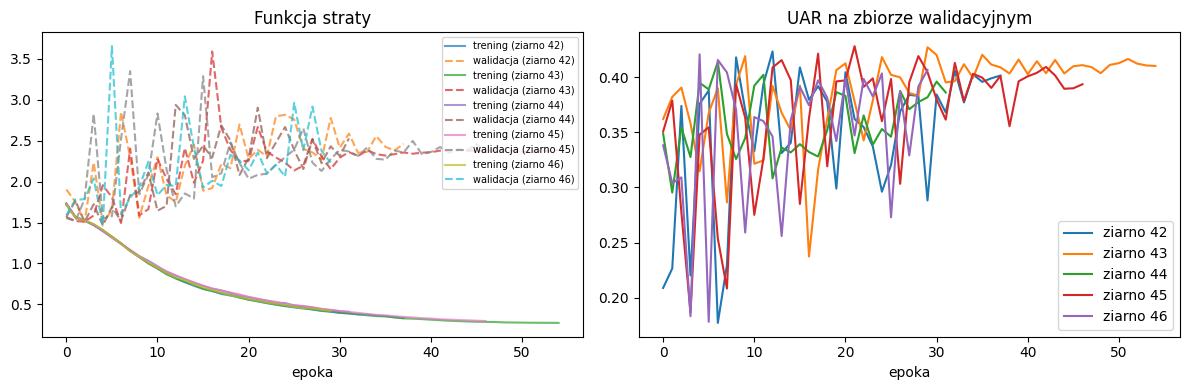

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for h, s in zip(all_hist, SEEDS):
    ax[0].plot(h["train_loss"], label=f"trening (ziarno {s})", alpha=.7)
    ax[0].plot(h["val_loss"], "--", label=f"walidacja (ziarno {s})", alpha=.7)
    ax[1].plot(h["val_uar"], label=f"ziarno {s}")
ax[0].set_title("Funkcja straty"); ax[0].set_xlabel("epoka"); ax[0].legend(fontsize=7)
ax[1].set_title("UAR na zbiorze walidacyjnym"); ax[1].set_xlabel("epoka"); ax[1].legend()
plt.tight_layout()
plt.savefig(RESULTS / "m4_stable_krzywe_uczenia.png", dpi=300, bbox_inches="tight")
plt.show()

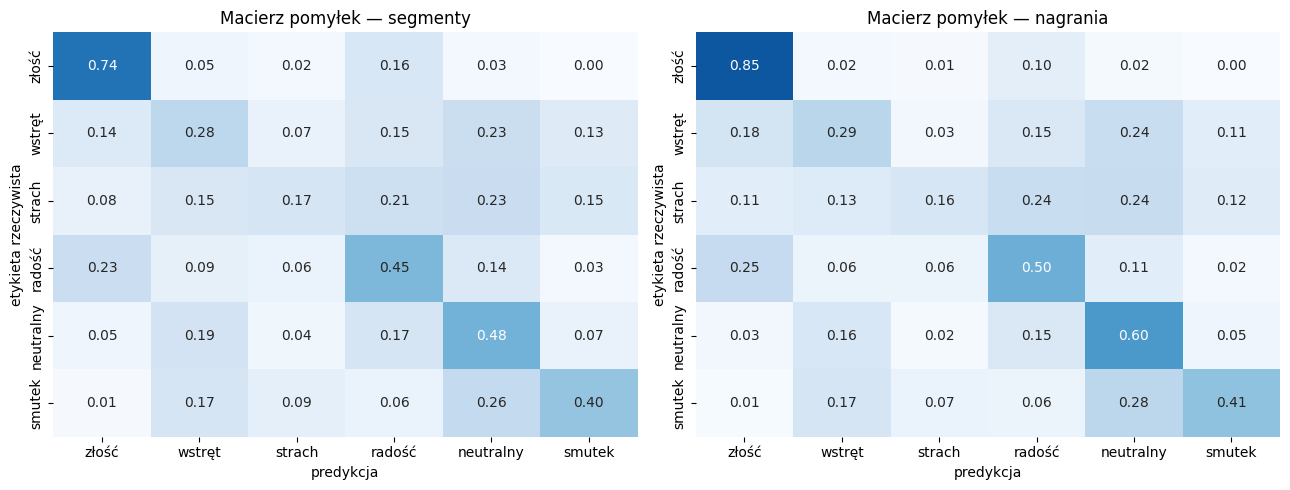

macierz uśredniona z 5 przebiegów
maks. odchylenie std na przekątnej: 0.174
klasa                 precyzja           czułość                F1
złość            0.598±0.049     0.848±0.039     0.698±0.020
wstręt           0.376±0.073     0.289±0.145     0.300±0.094
strach           0.564±0.132     0.163±0.104     0.221±0.112
radość           0.441±0.060     0.498±0.061     0.461±0.030
neutralny        0.395±0.068     0.596±0.174     0.450±0.025
smutek           0.586±0.029     0.412±0.069     0.480±0.047
średnia          0.493            0.468            0.435


In [15]:
labels_pl = [EMOTION_PL[e] for e in EMOTIONS]

def usrednij(klucz):
    cms = np.array([r[klucz] for r in runs], dtype=float)
    cmn = np.stack([c / c.sum(1, keepdims=True) for c in cms])
    return cmn.mean(0), cmn.std(0)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, (klucz, tt) in zip(ax, [("confusion_segment", "segmenty"),
                               ("confusion_utterance", "nagrania")]):
    cm, _ = usrednij(klucz)
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=labels_pl, yticklabels=labels_pl, ax=a, cbar=False)
    a.set_title(f"Macierz pomyłek — {tt}")
    a.set_xlabel("predykcja"); a.set_ylabel("etykieta rzeczywista")
plt.tight_layout()
plt.savefig(RESULTS / "m4_stable_macierz_pomylek.png", dpi=300, bbox_inches="tight")
plt.show()

_, cm_std = usrednij("confusion_utterance")
print(f"macierz uśredniona z {len(runs)} przebiegów")
print(f"maks. odchylenie std na przekątnej: {cm_std.diagonal().max():.3f}")

# raport klasyfikacji: srednia i odchylenie po przebiegach
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1 = [], [], []
for r in runs:
    p_, r_, f_, _ = precision_recall_fscore_support(
        np.array(r["true_utterance"]), np.array(r["pred_utterance"]),
        labels=range(N_CLASSES), zero_division=0)
    prec.append(p_); rec.append(r_); f1.append(f_)
prec, rec, f1 = np.array(prec), np.array(rec), np.array(f1)

print(f"{'klasa':12s}{'precyzja':>18s}{'czułość':>18s}{'F1':>18s}")
for i, e in enumerate(labels_pl):
    print(f"{e:12s}{prec[:,i].mean():>10.3f}±{prec[:,i].std():.3f}"
          f"{rec[:,i].mean():>10.3f}±{rec[:,i].std():.3f}"
          f"{f1[:,i].mean():>10.3f}±{f1[:,i].std():.3f}")
print(f"{'średnia':12s}{prec.mean():>10.3f}{'':7s}{rec.mean():>10.3f}{'':7s}{f1.mean():>10.3f}")

## 9. Koszt obliczeniowy

Warstwa rekurencyjna zrealizowana jako jawna pętla po krokach czasowych, podczas
gdy modele rzeczywiste wykorzystują zoptymalizowaną implementację cuDNN. Ma to
istotny wpływ na zmierzone wartości.

In [16]:
model = last_model.eval()
n_par = sum(p.numel() for p in model.parameters() if p.requires_grad)

xb, _ = next(iter(batches(ds["test"], 1)))
with torch.no_grad():
    for _ in range(20):
        model(stft_batch(xb) / RMS)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

t0 = time.time()
with torch.no_grad():
    for _ in range(200):
        model(stft_batch(xb) / RMS)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
latency = (time.time() - t0) / 200 * 1000

complexity = {
    "params_real": int(n_par),
    "latency_ms": float(latency),
    "mean_epoch_time_s": float(np.mean([r["mean_epoch_time"] for r in runs])),
    "device": str(DEVICE),
}
print(json.dumps(complexity, indent=2))

{
  "params_real": 543819,
  "latency_ms": 47.056987285614014,
  "mean_epoch_time_s": 145.73260482941066,
  "device": "cuda"
}


## 10. Zapis wyników

In [17]:
out = {
    "model": "m4_stable",
    "representation": "STFT zespolony, kompresja |z|^0.3",
    "input_shape": [1, N_BINS, N_FRAMES],
    "seeds": SEEDS,
    "runs": runs,
    "complexity": complexity,
    "history": all_hist,
    "confusion_utterance": confusion_matrix(y_f, pred_f).tolist(),
    "emotions": EMOTIONS,
}

out["config"] = {"label_smoothing": LABEL_SMOOTHING, "clip_norm": CLIP_NORM,
                 "scheduler": "OneCycleLR", "lr": LR}
with open(RESULTS / "m4_stable_5seeds.json", "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2, ensure_ascii=False)

torch.save(last_model.state_dict(), RESULTS / "m4_stable_5seeds.pt")
print(f"zapisano: {RESULTS/'m4_stable_5seeds.json'}")

zapisano: /kaggle/working/results/m4_stable_5seeds.json


## 11. Perturbacja informacji fazowej

Wytrenowanemu modelowi podawane są widma o zachowanym module i kącie fazowym
zastąpionym wartościami losowymi. Perturbacja wprowadzana jest wyłącznie na etapie
wnioskowania, wobec czego wynik opisuje wrażliwość modelu na zaburzenie wejścia,
nie zaś niezbędność informacji fazowej dla zadania.

In [18]:
PHASE_SEED = 1234
N_PHASE_DRAWS = 10

def stft_random_phase(wav, generator):
    Z = torch.stft(wav, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
                   window=WINDOW, center=CENTER, pad_mode="constant", return_complex=True)
    mag = Z.abs().clamp_min(1e-8) ** POWER_COMPRESSION
    phase = torch.rand(mag.shape, generator=generator, device=mag.device) * 2 * math.pi - math.pi
    return (mag * torch.exp(1j * phase)).unsqueeze(1)

last_model.eval()
y = ds["test"].y.cpu().numpy()
uars = []

for d in range(N_PHASE_DRAWS):
    g = torch.Generator(device=DEVICE); g.manual_seed(PHASE_SEED + d)
    probs = []
    with torch.no_grad():
        for xb, _ in batches(ds["test"], 128):
            probs.append(torch.softmax(last_model(stft_random_phase(xb, g) / RMS), 1))
    probs = torch.cat(probs).cpu().numpy()
    uars.append(recall_score(y, probs.argmax(1), average="macro"))

uar_orig = runs[-1]["segment"]["uar"]

print(f"checkpoint: ziarno {runs[-1]['seed']}")
print(f"UAR faza oryginalna : {uar_orig:.4f}")
print(f"UAR faza losowa     : {np.mean(uars):.4f} +/- {np.std(uars):.4f}  (n={N_PHASE_DRAWS})")
print(f"spadek              : {(uar_orig - np.mean(uars))*100:.2f} p.p.")

with open(RESULTS / "phase_ablation_base.json", "w") as f:
    json.dump({"checkpoint_seed": runs[-1]["seed"],
               "phase_seed": PHASE_SEED,
               "n_draws": N_PHASE_DRAWS,
               "uar_original": float(uar_orig),
               "uar_random_mean": float(np.mean(uars)),
               "uar_random_std": float(np.std(uars)),
               "uar_random_all": [float(u) for u in uars]}, f, indent=2)

checkpoint: ziarno 46
UAR faza oryginalna : 0.4333
UAR faza losowa     : 0.3190 +/- 0.0027  (n=10)
spadek              : 11.44 p.p.
